<a href="https://colab.research.google.com/github/hariniganesan31/Code-Alpha-Data-Science/blob/main/Car_Price_Prediction_with_Machine_Learning_task%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub pandas matplotlib seaborn scikit-learn

In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
path = kagglehub.dataset_download(
    "vijayaadithyanvg/car-price-predictionused-cars"
)

print("Dataset path:", path)
print("Files available:", os.listdir(path))

100%|██████████| 3.76k/3.76k [00:00<00:00, 4.56MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/vijayaadithyanvg/car-price-predictionused-cars/versions/1
Files available: ['car data.csv']


In [4]:
csv_files = [file for file in os.listdir(path) if file.endswith(".csv")]

print("CSV files found:", csv_files)

file_path = os.path.join(path, csv_files[0])

data = pd.read_csv(file_path)

print(data.head())

CSV files found: ['car data.csv']
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [5]:
print("Column names:")
print(data.columns.tolist())

print("\nDataset shape:", data.shape)

print("\nMissing values:")
print(data.isnull().sum())

Column names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

Dataset shape: (301, 9)

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [6]:
data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print(data.columns.tolist())

['car_name', 'year', 'selling_price', 'present_price', 'driven_kms', 'fuel_type', 'selling_type', 'transmission', 'owner']


In [7]:
possible_target_columns = [
    "price",
    "selling_price",
    "car_price",
    "sellingprice"
]

target_column = None

for column in possible_target_columns:
    if column in data.columns:
        target_column = column
        break

print("Target column:", target_column)

Target column: selling_price


In [8]:
print(data.columns.tolist())

['car_name', 'year', 'selling_price', 'present_price', 'driven_kms', 'fuel_type', 'selling_type', 'transmission', 'owner']


In [14]:
target_column = "selling_price"

In [15]:
data[target_column] = (
    data[target_column]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.replace("Rs.", "", regex=False)
)

data[target_column] = pd.to_numeric(data[target_column], errors="coerce")

data = data.dropna(subset=[target_column])

print(data[target_column].describe())

count    301.000000
mean       4.661296
std        5.082812
min        0.100000
25%        0.900000
50%        3.600000
75%        6.000000
max       35.000000
Name: selling_price, dtype: float64


In [16]:
id_columns = [
    column for column in data.columns
    if "id" in column or "unnamed" in column
]

data = data.drop(columns=id_columns, errors="ignore")

print("Removed columns:", id_columns)

Removed columns: []


In [17]:
name_columns = ["name", "car_name", "carname", "model"]

for column in name_columns:
    if column in data.columns:
        data["brand"] = data[column].astype(str).str.split().str[0]
        print("Brand feature created from:", column)
        break

print(data.head())

Brand feature created from: car_name
  car_name  year  selling_price  present_price  driven_kms fuel_type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  selling_type transmission  owner  brand  
0       Dealer       Manual      0   ritz  
1       Dealer       Manual      0    sx4  
2       Dealer       Manual      0   ciaz  
3       Dealer       Manual      0  wagon  
4       Dealer       Manual      0  swift  


In [18]:
print(data.isnull().sum())

car_name         0
year             0
selling_price    0
present_price    0
driven_kms       0
fuel_type        0
selling_type     0
transmission     0
owner            0
brand            0
dtype: int64


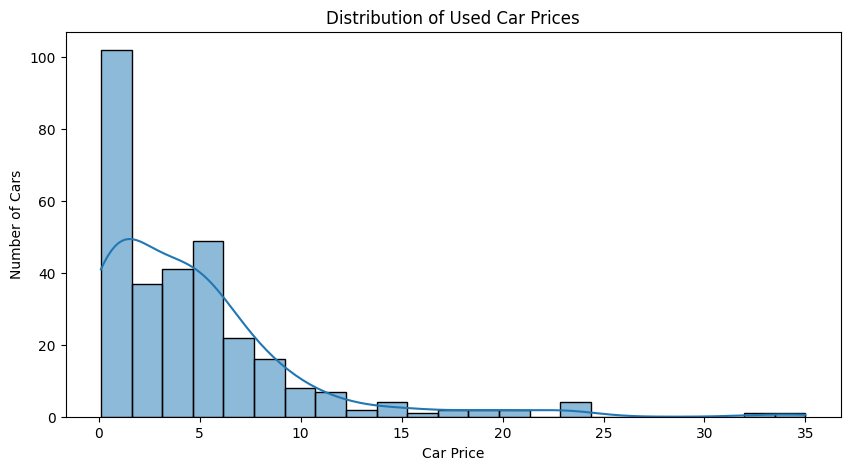

In [19]:
plt.figure(figsize=(10, 5))

sns.histplot(data[target_column], kde=True)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Car Price")
plt.ylabel("Number of Cars")

plt.show()

brand
land        35.000000
fortuner    18.685455
innova      12.777778
creta       11.800000
elantra     11.600000
vitara       9.250000
ciaz         7.472222
city         7.419231
corolla      6.848824
ertiga       6.775000
s            6.500000
verna        6.107857
baleno       5.850000
jazz         5.828571
xcent        4.966667
Name: selling_price, dtype: float64


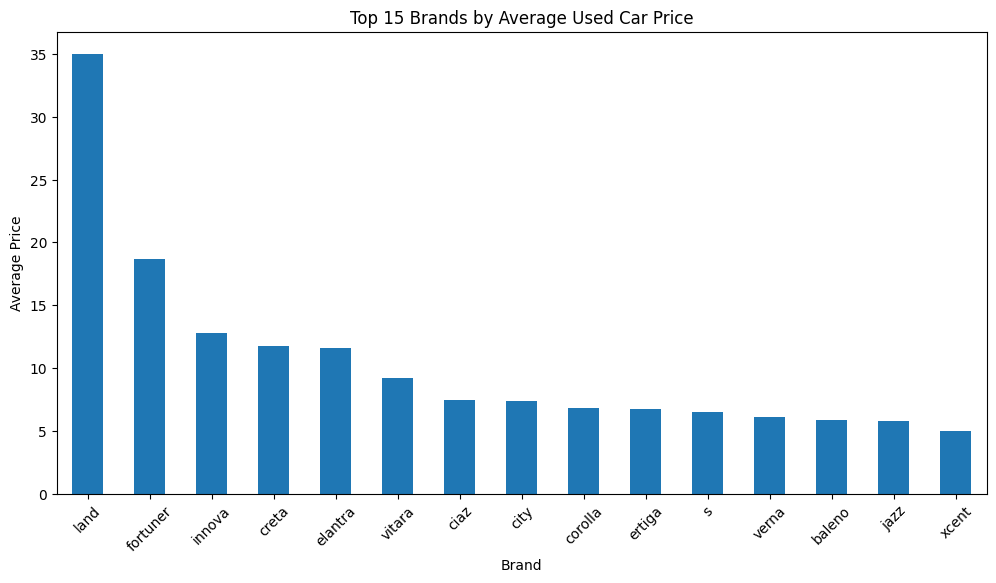

In [20]:
if "brand" in data.columns:
    brand_price = (
        data.groupby("brand")[target_column]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    print(brand_price)

    plt.figure(figsize=(12, 6))
    brand_price.plot(kind="bar")

    plt.title("Top 15 Brands by Average Used Car Price")
    plt.xlabel("Brand")
    plt.ylabel("Average Price")
    plt.xticks(rotation=45)

    plt.show()

In [21]:
X = data.drop(columns=[target_column])
y = data[target_column]

print("Input features:")
print(X.columns.tolist())

print("\nTarget column:", target_column)

Input features:
['car_name', 'year', 'present_price', 'driven_kms', 'fuel_type', 'selling_type', 'transmission', 'owner', 'brand']

Target column: selling_price


In [22]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['year', 'present_price', 'driven_kms', 'owner']
Categorical features: ['car_name', 'fuel_type', 'selling_type', 'transmission', 'brand']


In [23]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (240, 9)
Testing data shape: (61, 9)


In [25]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [27]:
y_pred = pipeline.predict(X_test)

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(results.head(10))

   Actual Price  Predicted Price
0          0.35          0.42220
1         10.11         10.35980
2          4.95          4.94975
3          0.15          0.20425
4          6.95          7.48175
5          7.45          6.82100
6          1.10          1.11795
7          0.50          0.59045
8          0.45          0.46385
9          6.00          6.58575


In [28]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 2))

Model Evaluation Results
Mean Absolute Error (MAE): 0.6
Mean Squared Error (MSE): 0.81
Root Mean Squared Error (RMSE): 0.9
R² Score: 0.96


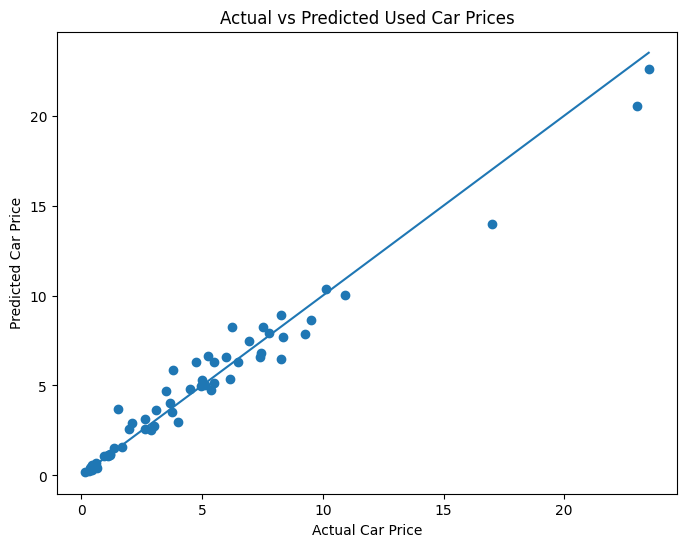

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Car Price")
plt.ylabel("Predicted Car Price")
plt.title("Actual vs Predicted Used Car Prices")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot([minimum, maximum], [minimum, maximum])

plt.show()

In [30]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

importance_values = pipeline.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(15))

                          Feature  Importance
1              num__present_price    0.872136
0                       num__year    0.056363
2                 num__driven_kms    0.031595
97    cat__transmission_Automatic    0.005159
132               cat__brand_land    0.003543
98       cat__transmission_Manual    0.003500
125           cat__brand_fortuner    0.003466
93          cat__fuel_type_Diesel    0.003343
84     cat__car_name_land cruiser    0.002661
117               cat__brand_city    0.002199
66             cat__car_name_city    0.001634
118            cat__brand_corolla    0.001567
95       cat__selling_type_Dealer    0.001498
67    cat__car_name_corolla altis    0.001300
96   cat__selling_type_Individual    0.001242


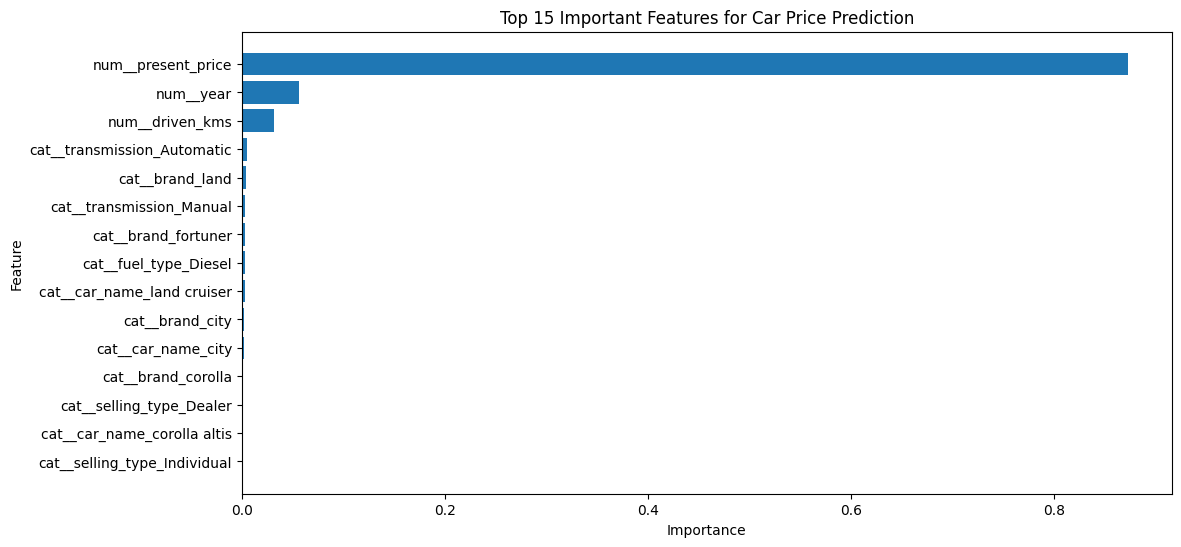

In [31]:
top_features = feature_importance.head(15)

plt.figure(figsize=(12, 6))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.title("Top 15 Important Features for Car Price Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

In [32]:
print("FINAL INSIGHTS")
print("1. The model predicts used car prices using available car-related features.")
print("2. Missing values are handled using imputation, and categorical features are converted using one-hot encoding.")
print("3. Random Forest Regressor predicts the price and is evaluated using MAE, MSE, RMSE, and R² score.")
print("4. Feature importance identifies the car details that influence price prediction.")
print("5. This model can help used-car dealers, buyers, sellers, and online marketplaces estimate fair car prices.")

FINAL INSIGHTS
1. The model predicts used car prices using available car-related features.
2. Missing values are handled using imputation, and categorical features are converted using one-hot encoding.
3. Random Forest Regressor predicts the price and is evaluated using MAE, MSE, RMSE, and R² score.
4. Feature importance identifies the car details that influence price prediction.
5. This model can help used-car dealers, buyers, sellers, and online marketplaces estimate fair car prices.
